In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

############################################
# Device setup
############################################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

############################################
# Model
############################################

class SimpleCNN(nn.Module):

    def __init__(self, width=64, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, width, 3, padding=1)
        self.conv2 = nn.Conv2d(width, width, 3, padding=1)
        self.conv3 = nn.Conv2d(width, width, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(width*4*4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


############################################
# Data
############################################

def load_cifar10(batch_size=512):

    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    train = torchvision.datasets.CIFAR10(
        "./data",
        train=True,
        download=True,
        transform=transform
    )

    test = torchvision.datasets.CIFAR10(
        "./data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4
    )

    test_loader = torch.utils.data.DataLoader(
        test,
        batch_size=batch_size,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True
    )

    return train_loader, test_loader


############################################
# Training
############################################

def train_epoch(model, loader, optimizer, scaler):

    model.train()
    loss_fn = nn.CrossEntropyLoss()

    for x,y in loader:

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            out = model(x)
            loss = loss_fn(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()


############################################
# Evaluation
############################################

def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            out = model(x)
            pred = out.argmax(1)

            correct += (pred==y).sum().item()
            total += y.size(0)

    return correct/total


############################################
# Global magnitude pruning
############################################

def global_prune(model, mask_dict, percent):

    weights = []

    for name,param in model.named_parameters():
        if "weight" in name:
            weights.append(param.data[mask_dict[name].bool()].abs())

    all_weights = torch.cat(weights)

    threshold = torch.quantile(all_weights, percent)

    for name,param in model.named_parameters():

        if "weight" in name:

            tensor = param.data
            mask = mask_dict[name]

            new_mask = torch.where(
                tensor.abs() < threshold,
                torch.zeros_like(tensor),
                torch.ones_like(tensor)
            )

            mask_dict[name] = mask * new_mask


############################################
# Apply pruning mask
############################################

def apply_mask(model, mask_dict):

    for name,param in model.named_parameters():

        if name in mask_dict:
            param.data.mul_(mask_dict[name])


############################################
# Lottery Ticket Experiment
############################################

def lottery_ticket_experiment(width):

    train_loader, test_loader = load_cifar10()

    model = SimpleCNN(width).to(device)

    initial_state = {k:v.clone() for k,v in model.state_dict().items()}

    mask_dict = {}
    for name,param in model.named_parameters():
        mask_dict[name] = torch.ones_like(param)

    results = []

    scaler = torch.cuda.amp.GradScaler()

    for round in range(8):

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        for epoch in range(5):
            train_epoch(model, train_loader, optimizer, scaler)

        acc = evaluate(model, test_loader)

        print("round", round, "accuracy", acc)

        results.append(acc)

        global_prune(model, mask_dict, 0.2)

        model.load_state_dict(initial_state)

        apply_mask(model, mask_dict)

    return results


############################################
# Run width scaling experiment
############################################

widths = [32,64,128,256]

all_results = {}

for w in widths:

    print("\nRunning width:", w)

    res = lottery_ticket_experiment(w)

    all_results[w] = res

Using device: cuda

Running width: 32


C:\Users\Dzu\AppData\Local\Temp\ipykernel_15116\860340164.py:207: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\Dzu\AppData\Local\Temp\ipykernel_15116\860340164.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


round 0 accuracy 0.5338
round 1 accuracy 0.5491
round 2 accuracy 0.5646
round 3 accuracy 0.5767
round 4 accuracy 0.5747
round 5 accuracy 0.5604
round 6 accuracy 0.5876
round 7 accuracy 0.58

Running width: 64
round 0 accuracy 0.6025
round 1 accuracy 0.6138
round 2 accuracy 0.6274
round 3 accuracy 0.6414
round 4 accuracy 0.64
round 5 accuracy 0.6622
round 6 accuracy 0.6629
round 7 accuracy 0.634

Running width: 128
round 0 accuracy 0.6451
round 1 accuracy 0.6412
round 2 accuracy 0.6866
round 3 accuracy 0.6967
round 4 accuracy 0.7069
round 5 accuracy 0.6962
round 6 accuracy 0.7082
round 7 accuracy 0.7122

Running width: 256
round 0 accuracy 0.692
round 1 accuracy 0.7075
round 2 accuracy 0.6793
round 3 accuracy 0.7124
round 4 accuracy 0.7125
round 5 accuracy 0.7208
round 6 accuracy 0.7193
round 7 accuracy 0.7123


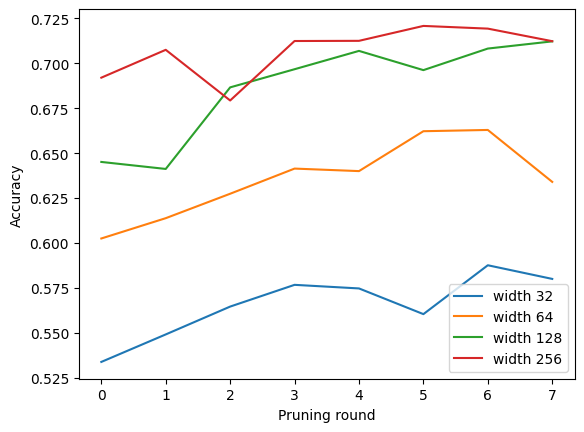

In [4]:
import matplotlib.pyplot as plt

for w in all_results:
    plt.plot(all_results[w], label=f"width {w}")

plt.xlabel("Pruning round")
plt.ylabel("Accuracy")
plt.legend()
plt.show()